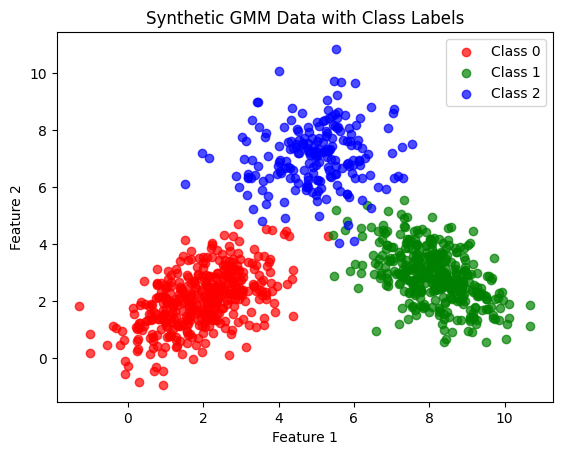

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
num_samples = 1000

# Parameters for the Gaussian Mixture Model
means = np.array([[2, 2], [8, 3], [5, 7]])
covariances = np.array([[[1, 0.5], [0.5, 1]], [[1, -0.5], [-0.5, 1]], [[1, 0], [0, 1]]])
weights = [0.4, 0.4, 0.2]

# Generate data points and assign class labels
data = []
labels = []
for i in range(num_samples):
    # Choose a component based on weights
    component = np.random.choice(len(weights), p=weights)

    # Generate a sample from the chosen component
    sample = np.random.multivariate_normal(means[component], covariances[component])

    data.append(sample)
    labels.append(component)

data = np.array(data)
labels = np.array(labels)

# Plot the generated data with class-specific colors
colors = ["r", "g", "b"]
for i in range(len(weights)):
    plt.scatter(
        data[labels == i, 0],
        data[labels == i, 1],
        alpha=0.7,
        label=f"Class {i}",
        c=colors[i],
    )

plt.title("Synthetic GMM Data with Class Labels")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:
from scipy.linalg import eigh
from scipy.sparse import coo_matrix


def classids_to_posteriors(classids, dtype="f4"):
    """Transform classids into a sparse matrix of 1 and 0 that can be interpreted as posteriors.

    Args:
        classids (np.array): class identifications
        dtype (str): dtype o output sparse matrix

    Returns:
        scipy.sparse.coo_matrix: sparse matrix of 1 and 0 that can be interpreted as posteriors
    """
    nsamples = np.array(classids).squeeze().shape[0]
    class2post = coo_matrix(
        (np.ones(nsamples, dtype), (classids, list(range(nsamples))))
    ).tocsr()
    return class2post


def get_class_means_between_and_within_covs(samples, classids, bias=True):
    """Return class means and the between and shread within class covariance matrix.

    Args:
        samples (np.array): input data
        classids (np.array): identification of classes
        bias (bool): type of normalization, see np.cov for more information

    Returns:
        tuple: class means, between class covariance, within class covariance
    """
    nsamples, dim = samples.shape
    sample2class = classids_to_posteriors(classids)
    counts = np.array(sample2class.sum(1))
    means = np.array(sample2class.dot(samples)) / counts
    between_cov = (means - samples.mean(0)) * np.sqrt(counts)
    between_cov = between_cov.T.dot(between_cov) / nsamples
    within_cov = np.cov(samples.T, bias=bias) - between_cov
    return means, between_cov, within_cov


def l2_norm(vec_or_matrix):
    """L2 normalization of vector array.

    Args:
        vec_or_matrix (np.array): one vector or array of vectors

    Returns:
        np.array: normalized vector or array of normalized vectors
    """
    if len(vec_or_matrix.shape) == 1:
        # linear vector
        return vec_or_matrix / np.linalg.norm(vec_or_matrix)
    elif len(vec_or_matrix.shape) == 2:
        return (
            vec_or_matrix / np.linalg.norm(vec_or_matrix, axis=1, ord=2)[:, np.newaxis]
        )
    else:
        raise ValueError(
            "Wrong number of dimensions, 1 or 2 is supported, not %i."
            % len(vec_or_matrix.shape)
        )

In [ ]:
embeddings = data
n_vectors, vector_dim = embeddings.shape

unique_idxs = list(set(labels))
idxs = np.array([unique_idxs.index(x) for x in labels])
# subtract mean
mean1 = np.mean(embeddings, axis=0)
embeddings -= mean1

# l2-norm
embeddings = l2_norm(embeddings)

# train LDA
means, between_cov, within_cov = get_class_means_between_and_within_covs(
    embeddings, idxs
)
# Hossein's magic - within_cov has probably smaller numbers on training data than within_cov on test data
# CW = CW + 0.01 * eye(size(CT, 1));
within_cov = within_cov + 0.01 * np.diag(np.ones(within_cov.shape[0]))

w, v = eigh(between_cov, within_cov)
index = np.argsort(w)[::-1]
v = v[:, index]

lda = v

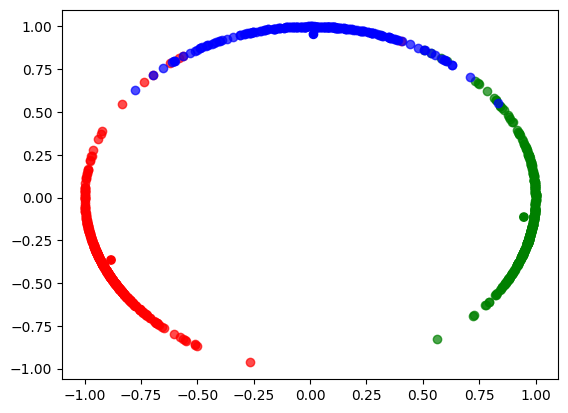

In [ ]:
from matplotlib.patches import Ellipse

for i in range(len(weights)):
    plt.scatter(
        embeddings[labels == i, 0],
        embeddings[labels == i, 1],
        alpha=0.7,
        label=f"Class {i}",
        c=colors[i],
    )
plt.scatter(means[:, 0], means[:, 1], c=["r", "g", "b"])
# eigenvalues, eigenvectors = np.linalg.eig(within_cov)
# angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
# width, height = 2 * np.sqrt(eigenvalues)

# ellipse = Ellipse(xy=means, width=width, height=height, angle=angle, edgecolor='blue', fc='None', lw=2, label='Covariance')
# plt.gca().add_patch(ellipse)

In [25]:
embeddings = embeddings.dot(lda)

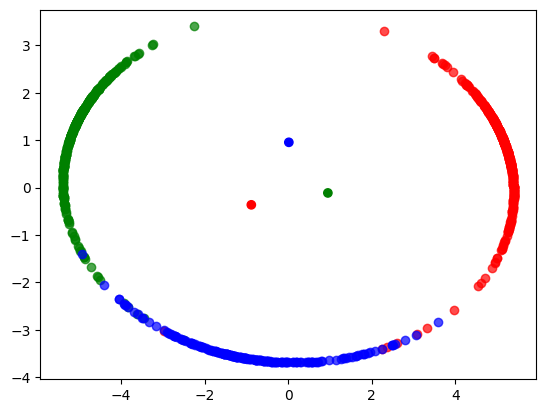

In [ ]:
from matplotlib.patches import Ellipse

for i in range(len(weights)):
    plt.scatter(
        embeddings[labels == i, 0],
        embeddings[labels == i, 1],
        alpha=0.7,
        label=f"Class {i}",
        c=colors[i],
    )
plt.scatter(means[:, 0], means[:, 1], c=["r", "g", "b"])
# eigenvalues, eigenvectors = np.linalg.eig(within_cov)
# angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
# width, height = 2 * np.sqrt(eigenvalues)

# ellipse = Ellipse(xy=means, width=width, height=height, angle=angle, edgecolor='blue', fc='None', lw=2, label='Covariance')
# plt.gca().add_patch(ellipse)

In [5]:
# subtract mean again
mean2 = np.mean(embeddings, axis=0)
embeddings -= mean2

# l2-norm again
embeddings = l2_norm(embeddings)

In [ ]:
np.isclose(means.dot(lda), mean2)

array([[False, False],
       [False, False],
       [False, False]])

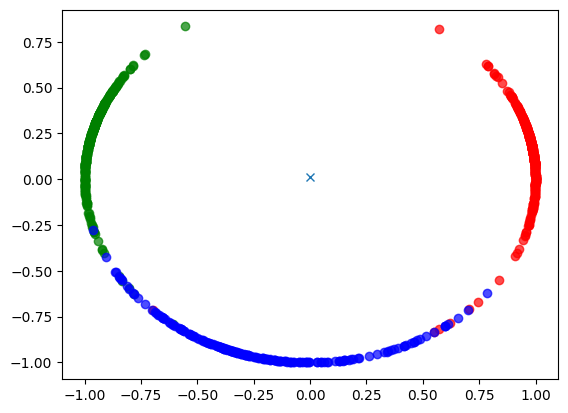

In [ ]:
from matplotlib.patches import Ellipse

for i in range(len(weights)):
    plt.scatter(
        embeddings[labels == i, 0],
        embeddings[labels == i, 1],
        alpha=0.7,
        label=f"Class {i}",
        c=colors[i],
    )
plt.plot(mean2[0], mean2[1], marker="x")
# eigenvalues, eigenvectors = np.linalg.eig(within_cov)
# angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
# width, height = 2 * np.sqrt(eigenvalues)

# ellipse = Ellipse(xy=means, width=width, height=height, angle=angle, edgecolor='blue', fc='None', lw=2, label='Covariance')
# plt.gca().add_patch(ellipse)